# Ley de Zipf

![](https://easy-peasy.ai/cdn-cgi/image/quality=80,format=auto,width=700/https://media.easy-peasy.ai/06d63b38-6397-4086-a861-f7cef59284b2/1caec269-9c9b-4e92-9886-17ea80945ace.png)
> Esto fue generador por una IA (no tengo pruebas pero tampoco dudas)

## Perspectivas formales

- Fueron el primer acercamiento al procesamiento del lenguaje natural. Sin embargo tienen varias **desventajas**
- Requieren **conocimiento previo de la lengua**
- Las herramientas son especificas de la lengua
- Los fenomenos que se presentan son muy amplios y dificilmente se pueden abarcar con reglas formales (muchos casos especiales)
- Las reglas tienden a ser rigidas y no admiten incertidumbre en el resultado

## Perspectiva estadística

- Puede integrar aspectos de la perspectiva formal
- Lidia mejor con la incertidumbre y es menos rigida que la perspectiva formal
- No requiere conocimiento profundo de la lengua. Se pueden obtener soluciones de forma no supervisada

### Modelos estadísticos

- Las **frecuencias** juegan un papel fundamental para hacer una descripción acertada del lenguaje
- Las frecuencias nos dan información de la **distribución de tokens**, de la cual podemos estimar probabilidades.
- Existen **leyes empíricas del lenguaje** que nos indican como se comportan las lenguas a niveles estadísticos
- A partir de estas leyes y otras reglas estadísticas podemos crear **modelos del lenguaje**; es decir, asignar probabilidades a las unidades lingüísticas

In [ ]:
# Bibliotecas
from collections import Counter
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]
import numpy as np
import pandas as pd

In [ ]:
mini_corpus = """Humanismo es un concepto polisémico que se aplica tanto al estudio de las letras humanas, los
estudios clásicos y la filología grecorromana como a una genérica doctrina o actitud vital que
concibe de forma integrada los valores humanos. Por otro lado, también se denomina humanis-
mo al «sistema de creencias centrado en el principio de que las necesidades de la sensibilidad
y de la inteligencia humana pueden satisfacerse sin tener que aceptar la existencia de Dios
y la predicación de las religiones», lo que se aproxima al laicismo o a posturas secularistas.
Se aplica como denominación a distintas corrientes filosóficas, aunque de forma particular,
al humanismo renacentista1 (la corriente cultural europea desarrollada de forma paralela al
Renacimiento a partir de sus orígenes en la Italia del siglo XV), caracterizado a la vez por su
vocación filológica clásica y por su antropocentrismo frente al teocentrismo medieval
"""
words = mini_corpus.replace("\n", " ").split(" ")
len(words)

146

In [ ]:
vocabulary = Counter(words)
vocabulary.most_common(10)

[('de', 11),
 ('la', 7),
 ('al', 6),
 ('que', 5),
 ('a', 5),
 ('y', 4),
 ('se', 3),
 ('las', 3),
 ('forma', 3),
 ('aplica', 2)]

In [ ]:
len(vocabulary)

101

In [ ]:
def get_frequencies(vocabulary: Counter, n: int) -> list:
    return [_[1] for _ in vocabulary.most_common(n)]

def plot_frequencies(frequencies: list, title="Freq of words", log_scale=False):
    x = list(range(1, len(frequencies)+1))
    plt.plot(x, frequencies, "-o")
    plt.xlabel("Freq rank (r)")
    plt.ylabel("Freq (f)")
    if log_scale:
        plt.xscale("log")
        plt.yscale("log")
    plt.title(title)

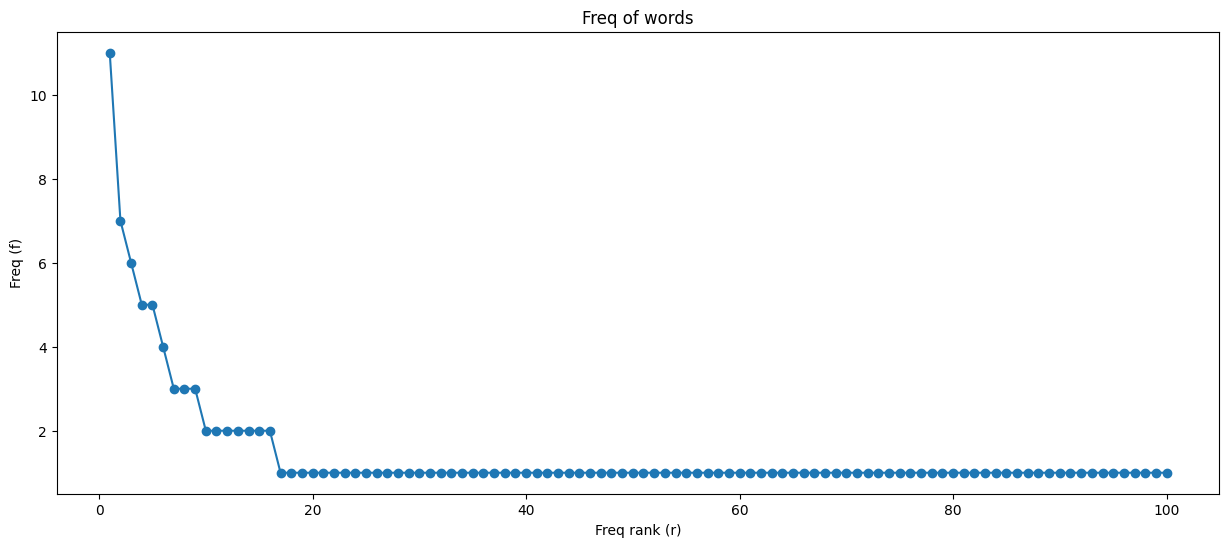

In [ ]:
frequencies = get_frequencies(vocabulary, 100)
plot_frequencies(frequencies)

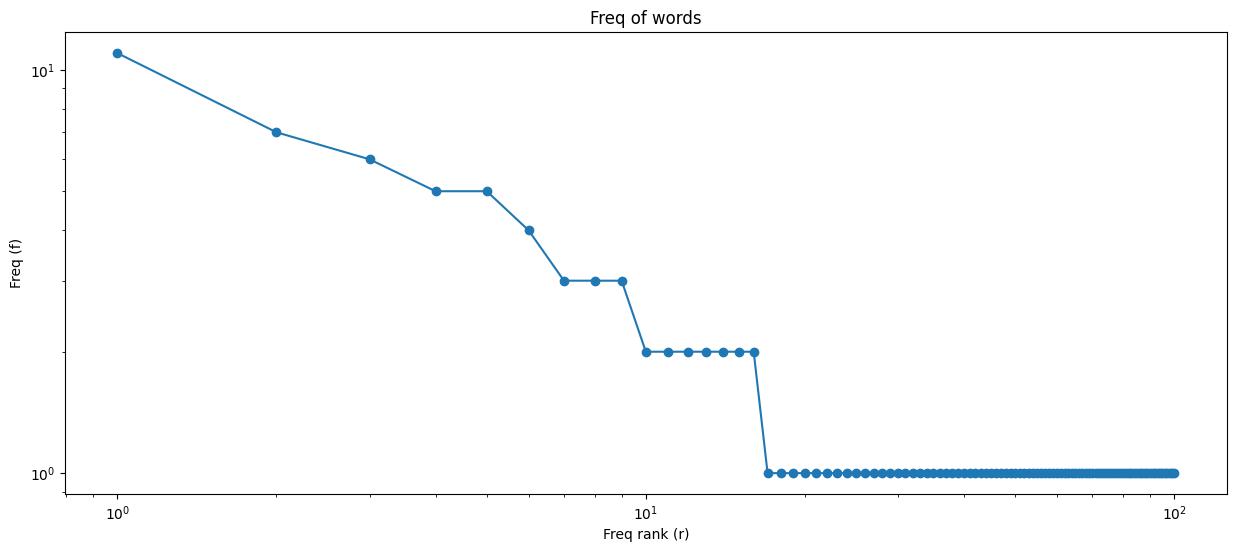

In [ ]:
plot_frequencies(frequencies, log_scale=True)


### ¿Qué pasará con más datos? 📊

In [ ]:
import nltk
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.


True

In [ ]:
from nltk.corpus import gutenberg

In [ ]:
def normalize(words: list) -> list:
    lower_words = list(map(str.lower, words))
    return [
        word
        for word in lower_words
        if word.isalpha()
    ]


In [ ]:
print(len(gutenberg.words()))

2621613


In [ ]:
word_freqs = Counter(normalize(gutenberg.words()))

In [ ]:
word_freqs.most_common(10)

[('the', 133583),
 ('and', 95442),
 ('of', 71267),
 ('to', 48057),
 ('a', 33960),
 ('in', 33580),
 ('i', 30265),
 ('that', 28798),
 ('he', 25857),
 ('it', 22303)]

In [ ]:
data = pd.DataFrame.from_dict(word_freqs, orient="index", columns=["freq"])
data.sort_values(by="freq", ascending=False, inplace=True)
data.reset_index(inplace=True)
data.rename(columns={"index": "word"}, inplace=True)

In [ ]:
data.head()

,word,freq
0,the,133583
1,and,95442
2,of,71267
3,to,48057
4,a,33960


In [ ]:
data[data["word"] == "plant"]

,word,freq
1983,plant,88


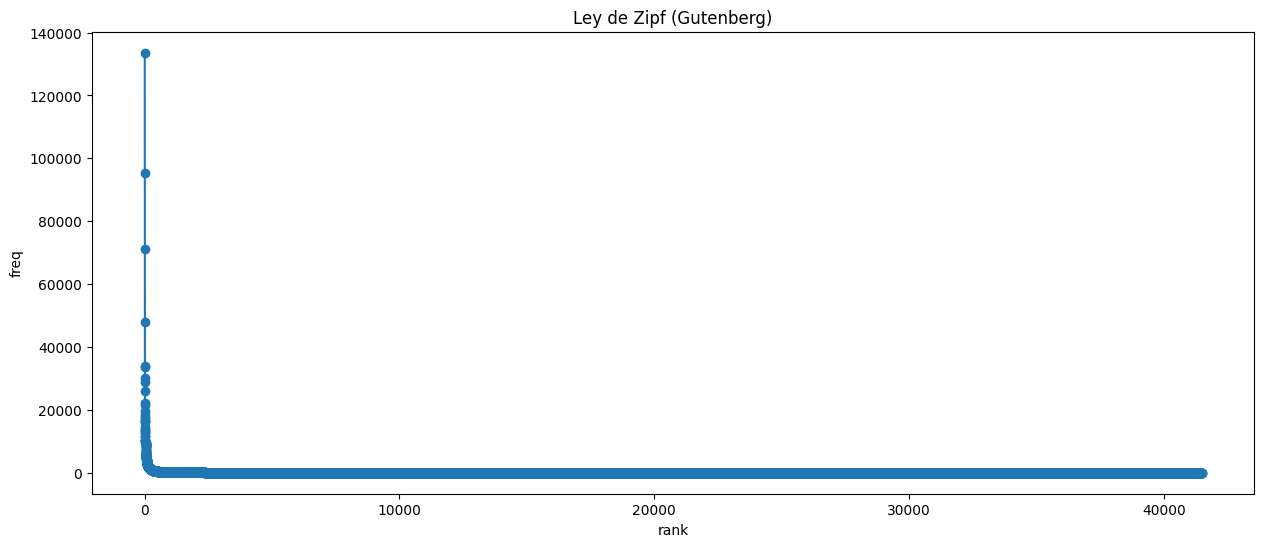

In [ ]:
data["freq"].plot(marker="o")
plt.title('Ley de Zipf (Gutenberg)')
plt.xlabel('rank')
plt.ylabel('freq')
plt.show()

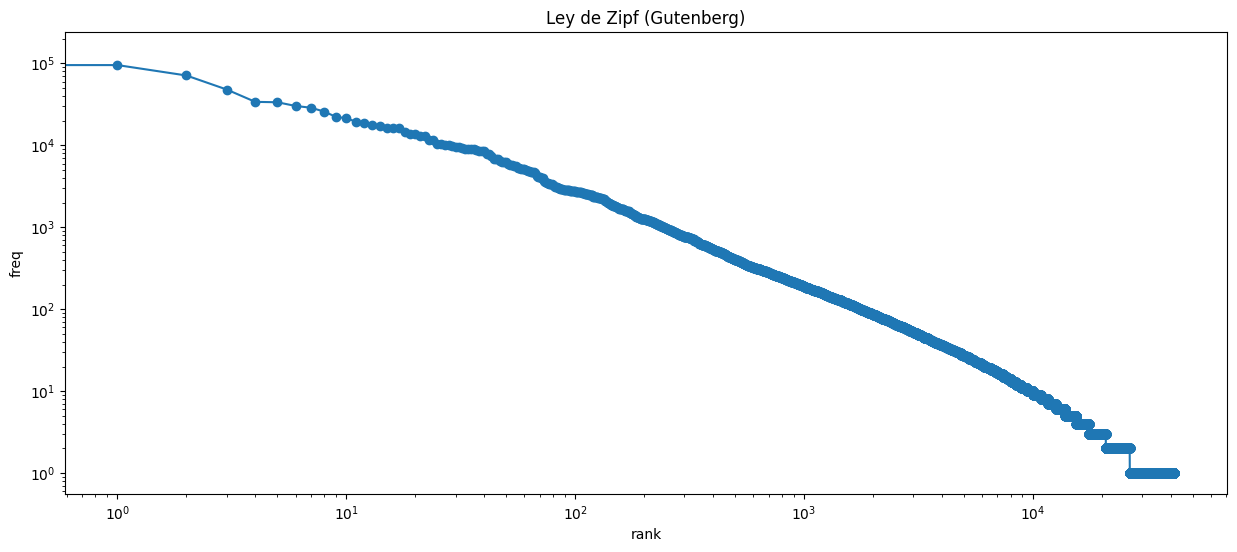

In [ ]:
data["freq"].plot(marker="o", loglog=True)
plt.title('Ley de Zipf (Gutenberg)')
plt.xlabel('rank')
plt.ylabel('freq')
plt.show()

In [ ]:
nltk.download("udhr")

[nltk_data] Downloading package udhr to /root/nltk_data...
[nltk_data]   Package udhr is already up-to-date!


True

In [ ]:
from nltk.corpus import udhr
udhr.fileids()

['Abkhaz-Cyrillic+Abkh',
 'Abkhaz-UTF8',
 'Achehnese-Latin1',
 'Achuar-Shiwiar-Latin1',
 'Adja-UTF8',
 'Afaan_Oromo_Oromiffa-Latin1',
 'Afrikaans-Latin1',
 'Aguaruna-Latin1',
 'Akuapem_Twi-UTF8',
 'Albanian_Shqip-Latin1',
 'Amahuaca',
 'Amahuaca-Latin1',
 'Amarakaeri-Latin1',
 'Amuesha-Yanesha-UTF8',
 'Arabela-Latin1',
 'Arabic_Alarabia-Arabic',
 'Asante-UTF8',
 'Ashaninca-Latin1',
 'Asheninca-Latin1',
 'Asturian_Bable-Latin1',
 'Aymara-Latin1',
 'Balinese-Latin1',
 'Bambara-UTF8',
 'Baoule-UTF8',
 'Basque_Euskara-Latin1',
 'Batonu_Bariba-UTF8',
 'Belorus_Belaruski-Cyrillic',
 'Belorus_Belaruski-UTF8',
 'Bemba-Latin1',
 'Bengali-UTF8',
 'Beti-UTF8',
 'Bichelamar-Latin1',
 'Bikol_Bicolano-Latin1',
 'Bora-Latin1',
 'Bosnian_Bosanski-Cyrillic',
 'Bosnian_Bosanski-Latin2',
 'Bosnian_Bosanski-UTF8',
 'Breton-Latin1',
 'Bugisnese-Latin1',
 'Bulgarian_Balgarski-Cyrillic',
 'Bulgarian_Balgarski-UTF8',
 'Cakchiquel-Latin1',
 'Campa_Pajonalino-Latin1',
 'Candoshi-Shapra-Latin1',
 'Caquinte-Latin

In [ ]:
import random

languages = [lang for lang in udhr.fileids() if lang.endswith("-UTF8")]
languages = random.choices(languages, k=300)

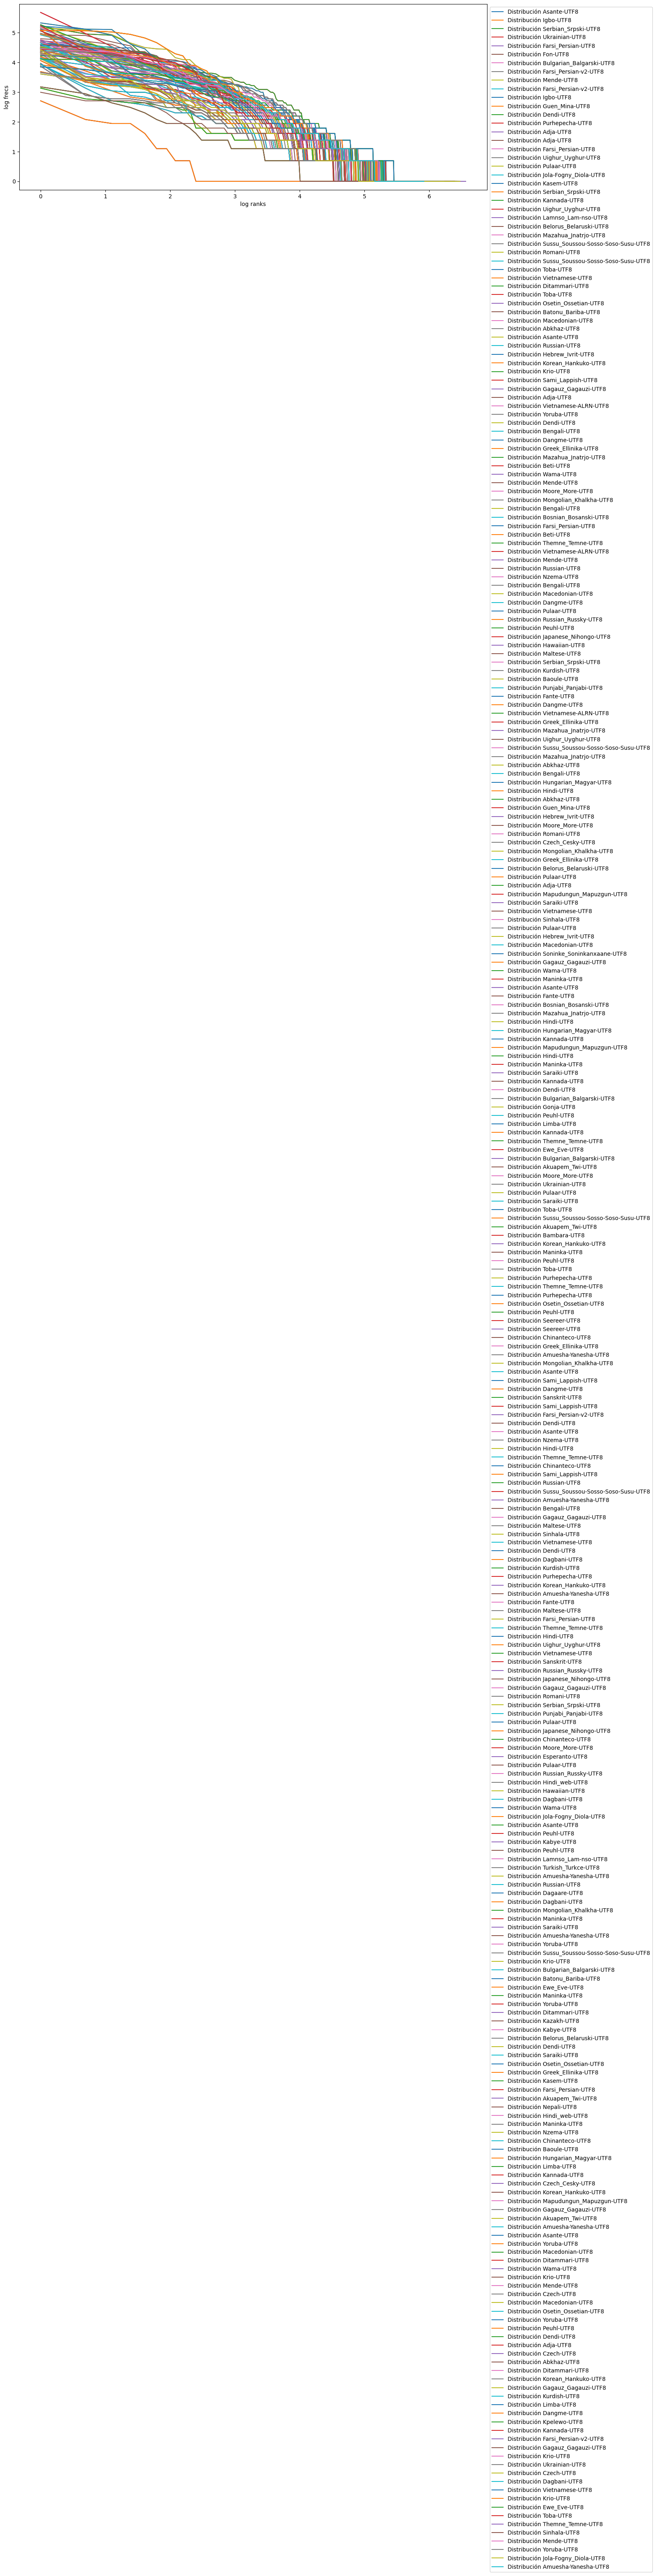

In [ ]:
# TODO: Cambiar nombre de dataframe
for lang in languages:
    corpus = normalize(udhr.words(lang))
    word_freqs = Counter(corpus)
    data = pd.DataFrame.from_dict(word_freqs, orient="index", columns=["freq"])
    data.sort_values(by="freq", ascending=False, inplace=True)
    data.reset_index(inplace=True)
    data.rename(columns={"index": "word"}, inplace=True)
    freqs = np.array(data["freq"])
    ranks = np.array(data.index) + 1
    plt.plot(np.log(ranks),np.log(freqs), label=f'Distribución {lang}')
plt.xlabel('log ranks')
plt.ylabel('log frecs')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

- Notamos que las frecuencias entre lenguas siguen un patrón
- Pocas palabras (tipos) son muy frecuentes, mientras que la mayoría de palabras ocurren pocas veces

De hecho, la frecuencia de la palabra que ocupa la posición r en el rank, es proporcional a $\frac{1}{r}$ (La palabra más frecuente ocurrirá aproximadamente el doble de veces que la segunda palabra más frecuente en el corpus y tres veces más que la tercer palabra más frecuente del corpus, etc)

$$f(w_r) \propto \frac{1}{r^α}$$

Donde:
- $r$ es el rank que ocupa la palabra en el corpus
- $f(w_r)$ es la frecuencia de la palabra en el corpus
- $\alpha$ es un parámetro, el valor dependerá del corpus o fenómeno que estemos observando

### Formulación de la Ley de Zipf:

$f(w_{r})=\frac{c}{r^{\alpha }}$

En la escala logarítimica:

$log(f(w_{r}))=log(\frac{c}{r^{\alpha }})$

$log(f(w_{r}))=log (c)-\alpha log (r)$

### ❓ ¿Cómo estimar el parámetro $\alpha$?

In [ ]:
from scipy.optimize import minimize

ranks = np.array(data.index) + 1
frecs = np.array(data['freq'])

# Inicialización
a0 = 1

# Función de minimización:
func = lambda a: sum((np.log(frecs)-(np.log(frecs[0])-a*np.log(ranks)))**2)

# Apliando minimos cuadrados
a_hat = minimize(func, a0).x[0]

print('alpha:', a_hat, '\nMSE:', func(a_hat))

alpha: 1.0873710470527633 
MSE: 10457.178937886281


In [ ]:
def plot_generate_zipf(alpha: np.float64, ranks: np.array, freqs: np.array) -> None:
    plt.plot(np.log(ranks),  np.log(freqs[0]) - alpha*np.log(ranks), color='g', label='Aproximación Zipf')

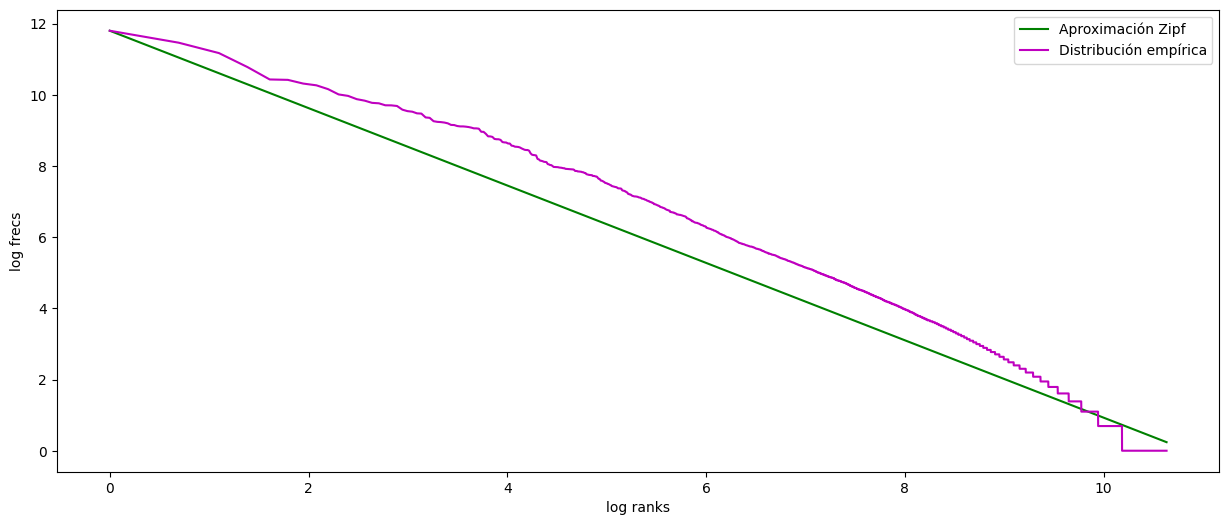

In [ ]:
plot_generate_zipf(a_hat, ranks, frecs)
plt.plot(np.log(ranks),np.log(frecs), color='m', label='Distribución empírica')
plt.xlabel('log ranks')
plt.ylabel('log frecs')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### Ley de Heap

Relación entre el número de **tokens** y **tipos** de un corpus

$$T \propto N^b$$

Dónde:

- $T = $ número de tipos
- $N = $ número de tokens
- $b = $ parámetro  

- **TOKENS**: Número total de palabras dentro del texto (incluidas repeticiones)
- **TIPOS**: Número total de palabras únicas en el texto

In [ ]:
# PLOT tokens vs types
total_tokens = data["freq"].sum()
total_types = len(data)

In [ ]:
corpus_sorted = data.sort_values(by="freq", ascending=False)
corpus_sorted["cum_tokens"] = corpus_sorted["freq"].cumsum()
corpus_sorted["cum_types"] = range(1, total_types +1)

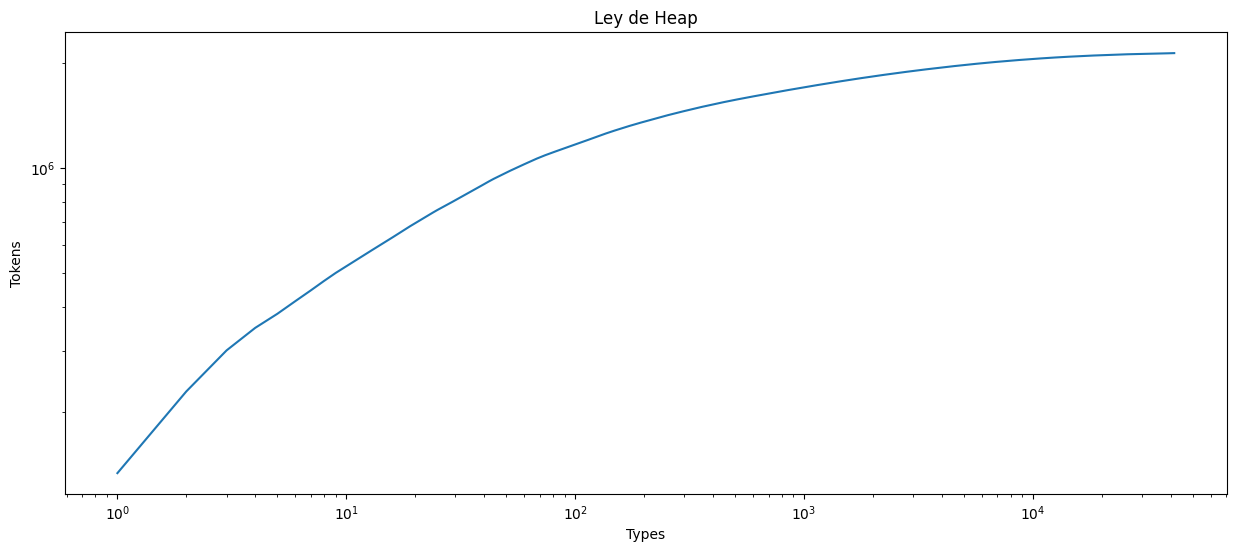

In [ ]:
# Plot de la ley de Heap
plt.plot(corpus_sorted['cum_types'], corpus_sorted['cum_tokens'])
plt.xscale("log")
plt.yscale("log")
plt.xlabel('Types')
plt.ylabel('Tokens')
plt.title('Ley de Heap')
plt.show()

### 📊 Ejercicio: Verifica si la ley de Zipf se muestra en el nahuátl

- Utiliza el corpus de la biblioteca `pyelotl`
- Calcula el parámetro $\alpha$
- Realiza el plot de la distribución empiríca vs la calculada

In [49]:
!pip install elotl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 18.1 MB/s eta 0:00:00


In [50]:
import elotl.corpus

axolotl = elotl.corpus.load("axolotl")

## Referencias

- https://pypi.org/project/elotl/
- [Zipf;s Mistery video](https://www.youtube.com/watch?v=fCn8zs912OE)
- [Descripción de corpus disponibles en nltk](https://www.nltk.org/book/ch02.html)